In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carregar e preparar os dados
df = pd.read_csv('dataset_ESAVI_limpo.csv')

In [2]:
# Garantir que a Idade é numérica e limpar valores nulos básicos para os gráficos
df['Idade Evento'] = pd.to_numeric(df['Idade Evento'], errors='coerce')
df_plot = df.dropna(subset=['Idade Evento', 'Sexo', 'Tipo de Evento', 'Raça/Cor', 'Houve atendimento médico?'])

In [3]:
# Limpar categorias de Sexo e Tipo de Evento que possam estar sujas (ex: espaços extras)
df_plot['Sexo'] = df_plot['Sexo'].str.strip()
df_plot['Tipo de Evento'] = df_plot['Tipo de Evento'].apply(lambda x: 'Erro de Imunização' if 'Erro de Imunização' in str(x) else ('Evento Adverso' if 'Evento Adverso' in str(x) else 'Outro'))
sns.set_theme(style="whitegrid")

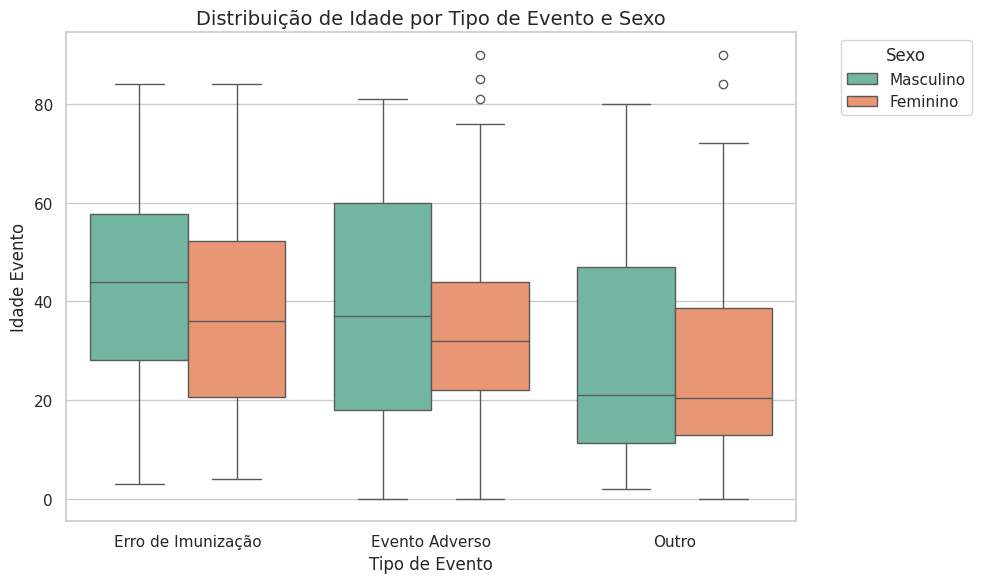

In [4]:
# ==============================================================================
# VISUALIZAÇÃO 1: Boxplot/Violinplot Multivariado (3 Variáveis)
# Variáveis: Tipo de Evento (X), Idade Evento (Y), Sexo (Cor/Hue)
# ==============================================================================

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_plot, x="Tipo de Evento", y="Idade Evento", hue="Sexo", palette="Set2")
plt.title("Distribuição de Idade por Tipo de Evento e Sexo", fontsize=14)
plt.legend(title="Sexo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- INTERPRETAÇÃO NO NOTEBOOK (Célula Markdown) ---
"""
### Interpretação da Visualização 1 (Boxplot Multivariado):
Esta visualização codifica três dimensões: Categoria do Evento (X), Idade (Y) e Sexo (Cor).
- **Dispersão de Idade**: Podemos observar qual faixa etária concentra mais 'Erros de Imunização' versus 'Eventos Adversos'.
- **Interação com Sexo**: O uso da cor (hue) revela se há uma discrepância de idade entre homens e mulheres para o mesmo tipo de evento (ex: se mulheres mais velhas relatam mais eventos adversos do que homens na mesma faixa etária).
- **Outliers**: Os pontos fora das 'caixas' ajudam a identificar idades atípicas (muito altas ou muito baixas) que sofreram algum desses eventos.
"""

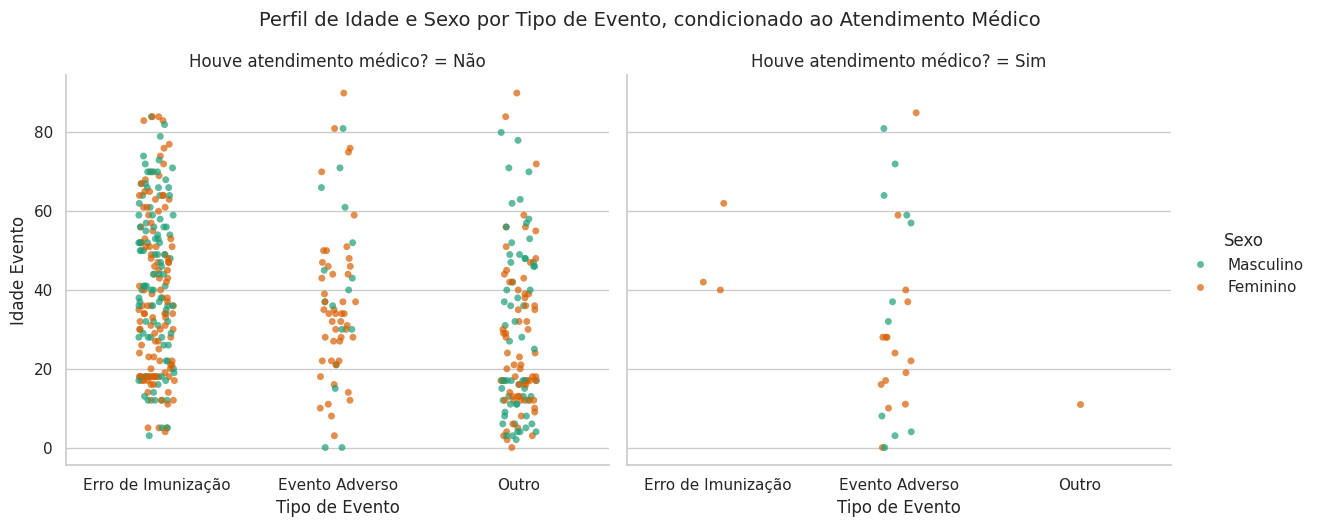

In [5]:
# ==============================================================================
# VISUALIZAÇÃO 2: Facetamento (FacetGrid) com Histograma (4 Variáveis)
# Variáveis: Atendimento Médico (Colunas), Tipo de Evento (X), Idade (Y), Sexo (Cor/Hue)
# ==============================================================================
# Vamos usar um swarmplot ou stripplot facetado, já que temos poucos dados de atendimento.

g = sns.catplot(
    data=df_plot, 
    x="Tipo de Evento", 
    y="Idade Evento", 
    hue="Sexo", 
    col="Houve atendimento médico?", 
    kind="strip", 
    jitter=True, 
    alpha=0.7, 
    height=5, 
    aspect=1.2,
    palette="Dark2"
)
g.fig.suptitle("Perfil de Idade e Sexo por Tipo de Evento, condicionado ao Atendimento Médico", y=1.05, fontsize=14)
plt.show()

# --- INTERPRETAÇÃO NO NOTEBOOK (Célula Markdown) ---
"""
### Interpretação da Visualização 2 (Facetamento):
Aqui aplicamos o conceito de 'Grades' de VanderPlas para adicionar uma quarta dimensão espacial.
- A divisão em painéis (facetas) pela variável **'Houve atendimento médico?'** permite isolar imediatamente os casos mais graves (que buscaram hospital/médico).
- Observamos rapidamente no painel 'Sim' qual é o perfil (Idade, Sexo e Tipo de Evento) das pessoas que precisaram de intervenção, contrastando diretamente com a grande nuvem de pontos no painel 'Não'.
- Isso reduz a sobreposição visual (overplotting) e conta uma história mais segmentada sobre os impactos das reações.
"""

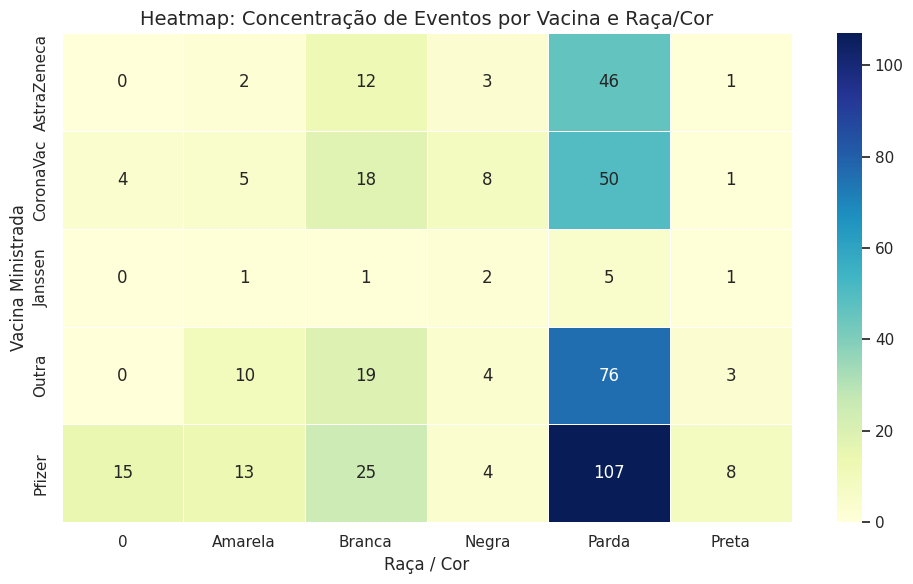

In [6]:
# ==============================================================================
# VISUALIZAÇÃO 3: Heatmap Multivariado de Categorias (Densidade Cruzada)
# Variáveis: Imunobiológico Simplificado (Y), Raça/Cor (X), Frequência (Intensidade da Cor)
# ==============================================================================
# Como os nomes das vacinas são longos, vamos simplificar para a visualização

def simplificar_vacina(nome):
    nome = str(nome).lower()
    if 'pfizer' in nome: return 'Pfizer'
    elif 'astrazeneca' in nome: return 'AstraZeneca'
    elif 'butantan' in nome or 'coronavac' in nome: return 'CoronaVac'
    elif 'janssen' in nome: return 'Janssen'
    else: return 'Outra'

df_plot['Vacina_Simplificada'] = df_plot['Imunobiológico (vacina)'].apply(simplificar_vacina)

# Criando a tabela de contingência
tabela_cruzada = pd.crosstab(df_plot['Vacina_Simplificada'], df_plot['Raça/Cor'])

plt.figure(figsize=(10, 6))
sns.heatmap(tabela_cruzada, annot=True, cmap="YlGnBu", fmt='d', linewidths=.5)
plt.title("Heatmap: Concentração de Eventos por Vacina e Raça/Cor", fontsize=14)
plt.ylabel("Vacina Ministrada")
plt.xlabel("Raça / Cor")
plt.tight_layout()
plt.show()

# --- INTERPRETAÇÃO NO NOTEBOOK (Célula Markdown) ---
"""
### Interpretação da Visualização 3 (Heatmap de Categorias):
Na falta de múltiplas variáveis numéricas, usamos o agrupamento bidimensional (semelhante ao Hexbin em conceito) para dados categóricos.
- O Heatmap mostra a **interação de densidade** entre as categorias geodemográficas e o tipo de vacina.
- Em vez de ler tabelas extensas, a intensidade da cor acusa imediatamente os maiores "pontos quentes" (hotspots) do dataset (ex: Eventos em indivíduos pardos e brancos que tomaram Pfizer e AstraZeneca).
- Serve como uma excelente ferramenta de triagem multivariada para direcionar investigações mais profundas de políticas de saúde pública.
"""